# NIFTY 50 Quant Strategy Research

This notebook is the starting point for the project.  
For now I am only preparing the market data and the indicators that will be used later in the strategies.

Phase 1 covers:
- NIFTY 50 historical data
- basic data checks
- returns and drawdown
- SMA, RSI, momentum and volatility


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

print("Python:", sys.version.split()[0])
print("Python executable:", sys.executable)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("yfinance:", yf.__version__)
print("\nSetup OK")


Python: 3.12.10
Python executable: c:\quantitative-trading-backtesting\.venv\Scripts\python.exe
pandas: 3.0.5
numpy: 2.5.2
yfinance: 1.5.2

Setup OK


## Setup

Basic project settings and file paths.


In [2]:
TICKER = "^NSEI"
START_DATE = "2015-01-01"
END_DATE = "2026-08-11"

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
IMAGE_DIR = PROJECT_ROOT / "images"

RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = RAW_DATA_DIR / "nifty50_daily.csv"

print("Project root:", PROJECT_ROOT)
print("Data cache:", DATA_PATH)


Project root: c:\quantitative-trading-backtesting
Data cache: c:\quantitative-trading-backtesting\data\raw\nifty50_daily.csv


## Get NIFTY 50 data

Download daily NIFTY 50 data from Yahoo Finance and save a local copy.


In [3]:
nifty = yf.Ticker(TICKER)

data = nifty.history(
    start=START_DATE,
    end=END_DATE,
    interval="1d",
    auto_adjust=False,
    actions=False,
)

if data.empty:
    raise RuntimeError(
        "No market data was returned. Check your internet connection and try the cell again."
    )

# Keep only the columns I need
wanted_columns = ["Open", "High", "Low", "Close", "Adj Close", "Volume"]
available_columns = [col for col in wanted_columns if col in data.columns]
data = data[available_columns].copy()

# Remove timezone so dates stay clean in the CSV
data.index = pd.to_datetime(data.index)
if data.index.tz is not None:
    data.index = data.index.tz_localize(None)

data.index.name = "Date"
data = data.sort_index()

data.to_csv(DATA_PATH)

print(f"Downloaded {len(data):,} daily rows.")
print(f"First date: {data.index.min().date()}")
print(f"Last date : {data.index.max().date()}")
display(data.head())


Downloaded 2,856 daily rows.
First date: 2015-01-02
Last date : 2026-08-10


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2015-01-02,8288.700195,8410.599609,8288.700195,8395.450195,8395.450195,101900
2015-01-05,8407.950195,8445.599609,8363.900391,8378.400391,8378.400391,118200
2015-01-06,8325.299805,8327.849609,8111.350098,8127.350098,8127.350098,172800
2015-01-07,8118.649902,8151.200195,8065.450195,8102.100098,8102.100098,164100
2015-01-08,8191.399902,8243.500000,8167.299805,8234.599609,8234.599609,143800


## Check the data

A few checks before using the data for any calculations.


In [4]:
price_columns = ["Open", "High", "Low", "Close"]
missing_by_column = data.isna().sum()
duplicate_dates = int(data.index.duplicated().sum())

non_positive_prices = int((data[price_columns] <= 0).any(axis=1).sum())
high_below_low = int((data["High"] < data["Low"]).sum())
high_below_open_close = int(
    (data["High"] < data[["Open", "Close"]].max(axis=1)).sum()
)
low_above_open_close = int(
    (data["Low"] > data[["Open", "Close"]].min(axis=1)).sum()
)

quality_report = pd.Series({
    "rows": len(data),
    "duplicate_dates": duplicate_dates,
    "rows_with_non_positive_price": non_positive_prices,
    "high_below_low": high_below_low,
    "high_below_open_or_close": high_below_open_close,
    "low_above_open_or_close": low_above_open_close,
}, name="value")

display(quality_report.to_frame())
print("\nMissing values:")
display(missing_by_column.to_frame("missing"))

critical_issues = (
    duplicate_dates
    + non_positive_prices
    + high_below_low
    + high_below_open_close
    + low_above_open_close
)

if critical_issues == 0:
    print("OHLC checks passed.")
else:
    print("Check the OHLC issues above before moving on.")


,value
rows,2856
duplicate_dates,0
rows_with_non_positive_price,0
high_below_low,0
high_below_open_or_close,0
low_above_open_or_close,0



Missing values:


,missing
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


OHLC checks passed.


## Clean data

Remove duplicate dates and rows where the main OHLC values are missing.


In [5]:
market = data.copy()

market = market[~market.index.duplicated(keep="first")]
market = market.dropna(subset=price_columns)

if (market[price_columns] <= 0).any().any():
    raise ValueError("Non-positive OHLC prices remain after cleaning.")

if (market["High"] < market["Low"]).any():
    raise ValueError("At least one row has High < Low.")

print(f"Rows before cleaning: {len(data):,}")
print(f"Rows after cleaning : {len(market):,}")


Rows before cleaning: 2,856
Rows after cleaning : 2,856


## Volume check

Index volume is not always useful, so I check it before using it anywhere in the project.


In [6]:
if "Volume" in market.columns:
    valid_volume_share = float((market["Volume"].fillna(0) > 0).mean())
    volume_reliable = valid_volume_share >= 0.95
else:
    valid_volume_share = 0.0
    volume_reliable = False

print(f"Share of rows with positive volume: {valid_volume_share:.2%}")

if volume_reliable:
    print("Volume looks usable.")
else:
    print("Volume is mostly missing/zero, so I will not use it in the strategies.")


Share of rows with positive volume: 98.98%
Volume looks usable.


## Indicator functions

Small helper functions for the indicators used in this project.


In [7]:
def simple_moving_average(series, window):
    return series.rolling(window=window, min_periods=window).mean()


def rsi(series, window=14):
    change = series.diff()

    gains = change.clip(lower=0)
    losses = -change.clip(upper=0)

    avg_gain = gains.ewm(alpha=1 / window, adjust=False, min_periods=window).mean()
    avg_loss = losses.ewm(alpha=1 / window, adjust=False, min_periods=window).mean()

    rs = avg_gain / avg_loss.replace(0, np.nan)
    rsi_value = 100 - (100 / (1 + rs))

    # Handle the zero-loss case
    rsi_value = rsi_value.where(avg_loss != 0, 100.0)

    return rsi_value


def rolling_volatility(returns, window=20, trading_days=252):
    return returns.rolling(window=window, min_periods=window).std() * np.sqrt(trading_days)


def drawdown_from_price(series):
    rolling_peak = series.cummax()
    return series / rolling_peak - 1


## Add features


In [8]:
market["Daily_Return"] = market["Close"].pct_change()
market["Log_Return"] = np.log(market["Close"] / market["Close"].shift(1))
market["Cumulative_Return"] = (1 + market["Daily_Return"].fillna(0)).cumprod() - 1

market["SMA_20"] = simple_moving_average(market["Close"], 20)
market["SMA_50"] = simple_moving_average(market["Close"], 50)

market["RSI_14"] = rsi(market["Close"], 14)

# Roughly one trading month
market["Momentum_20"] = market["Close"].pct_change(20)

market["Rolling_Volatility_20"] = rolling_volatility(market["Daily_Return"], 20)
market["Rolling_Max"] = market["Close"].cummax()
market["Drawdown"] = drawdown_from_price(market["Close"])

feature_columns = [
    "Close",
    "Daily_Return",
    "Log_Return",
    "Cumulative_Return",
    "SMA_20",
    "SMA_50",
    "RSI_14",
    "Momentum_20",
    "Rolling_Volatility_20",
    "Drawdown",
]

display(market[feature_columns].tail())


,Close,Daily_Return,Log_Return,Cumulative_Return,SMA_20,SMA_50,RSI_14,Momentum_20,Rolling_Volatility_20,Drawdown
Date,,,,,,,,,,
2026-08-04,24614.900391,-0.006434,-0.006455,1.931933,24159.065039,23944.181914,61.772833,0.008861,0.135191,-0.065087
2026-08-05,24624.650391,0.000396,0.000396,1.933095,24196.195020,23956.040938,61.963778,0.031094,0.108401,-0.064717
2026-08-06,24636.000000,0.000461,0.000461,1.934447,24229.854980,23970.486953,62.200472,0.028094,0.108244,-0.064286
2026-08-07,24570.650391,-0.002653,-0.002656,1.926663,24248.042480,23983.756953,59.889546,0.015027,0.103943,-0.066768
2026-08-10,24583.800781,0.000535,0.000535,1.928229,24266.682520,24004.477969,60.209913,0.015398,0.103923,-0.066268


## Quick checks

Make sure the indicator values look reasonable before moving ahead.


In [9]:
checks = {
    "daily_return_non_null": int(market["Daily_Return"].notna().sum()),
    "sma20_non_null": int(market["SMA_20"].notna().sum()),
    "sma50_non_null": int(market["SMA_50"].notna().sum()),
    "rsi14_non_null": int(market["RSI_14"].notna().sum()),
    "momentum20_non_null": int(market["Momentum_20"].notna().sum()),
    "volatility20_non_null": int(market["Rolling_Volatility_20"].notna().sum()),
}

display(pd.Series(checks, name="count").to_frame())

rsi_out_of_range = int(((market["RSI_14"] < 0) | (market["RSI_14"] > 100)).sum())
positive_drawdowns = int((market["Drawdown"] > 1e-12).sum())

print("RSI values outside [0, 100]:", rsi_out_of_range)
print("Positive drawdown values:", positive_drawdowns)

if rsi_out_of_range == 0 and positive_drawdowns == 0:
    print("Indicator checks passed.")


,count
daily_return_non_null,2855
sma20_non_null,2837
sma50_non_null,2807
rsi14_non_null,2842
momentum20_non_null,2836
volatility20_non_null,2836


RSI values outside [0, 100]: 0
Positive drawdown values: 0
Indicator checks passed.


## Market overview


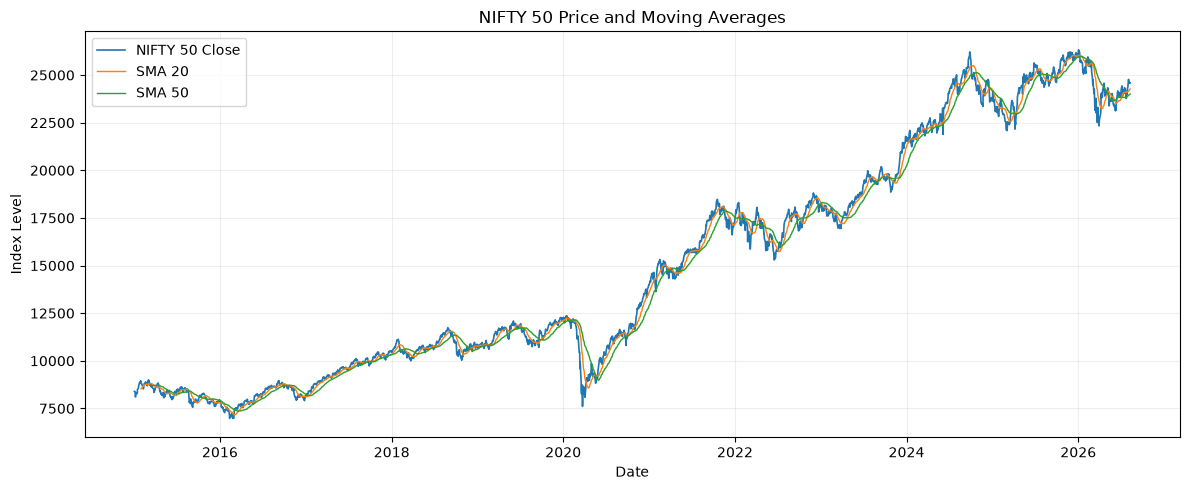

In [10]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(market.index, market["Close"], label="NIFTY 50 Close", linewidth=1.2)
ax.plot(market.index, market["SMA_20"], label="SMA 20", linewidth=1.0)
ax.plot(market.index, market["SMA_50"], label="SMA 50", linewidth=1.0)
ax.set_title("NIFTY 50 Price and Moving Averages")
ax.set_xlabel("Date")
ax.set_ylabel("Index Level")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


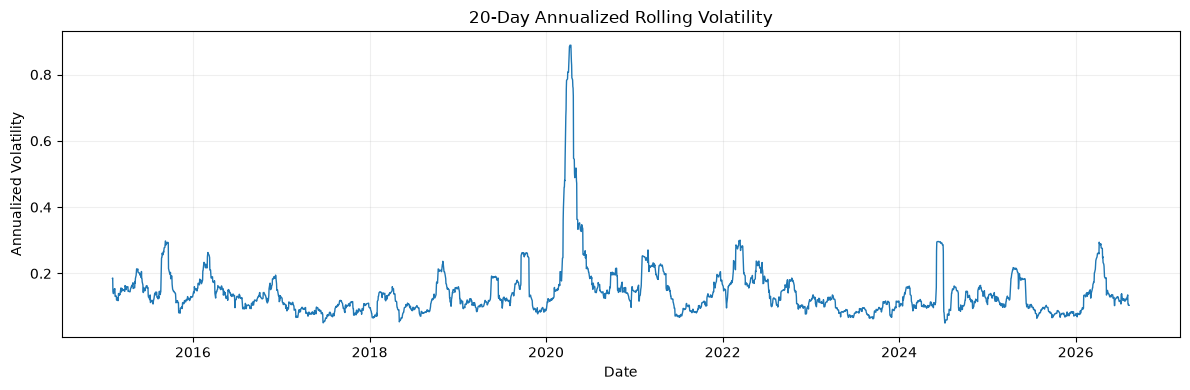

In [11]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(market.index, market["Rolling_Volatility_20"], linewidth=1.0)
ax.set_title("20-Day Annualized Rolling Volatility")
ax.set_xlabel("Date")
ax.set_ylabel("Annualized Volatility")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


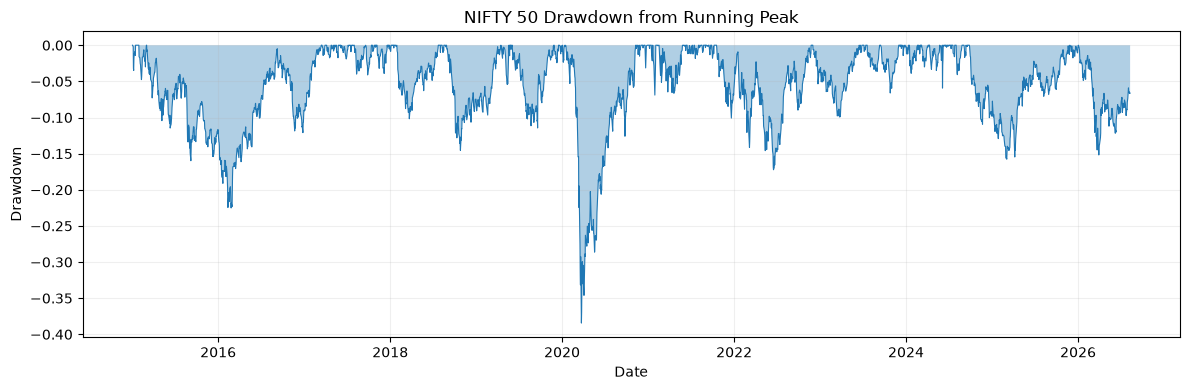

In [12]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(market.index, market["Drawdown"], 0, alpha=0.35)
ax.plot(market.index, market["Drawdown"], linewidth=0.8)
ax.set_title("NIFTY 50 Drawdown from Running Peak")
ax.set_xlabel("Date")
ax.set_ylabel("Drawdown")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


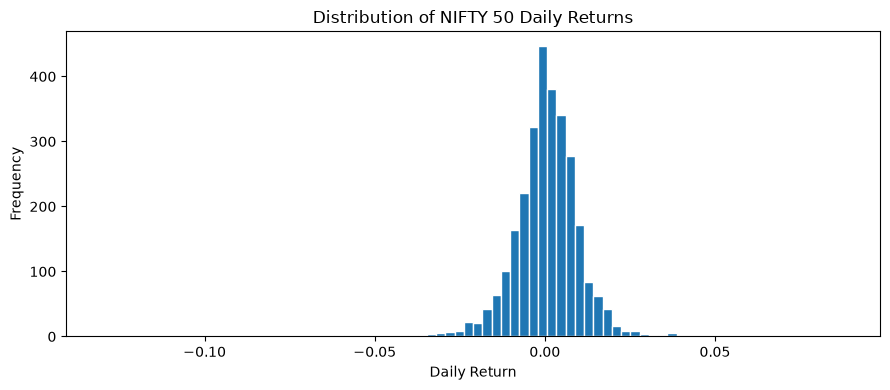

In [13]:
returns_for_plot = market["Daily_Return"].dropna()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(returns_for_plot, bins=80, edgecolor="white")
ax.set_title("Distribution of NIFTY 50 Daily Returns")
ax.set_xlabel("Daily Return")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()


## 10. Phase 1 summary


In [14]:
years_covered = (market.index.max() - market.index.min()).days / 365.25

summary = pd.Series({
    "Ticker": TICKER,
    "Rows": len(market),
    "Start": market.index.min().date(),
    "End": market.index.max().date(),
    "Years covered": round(years_covered, 2),
    "Total close-price return": market["Close"].iloc[-1] / market["Close"].iloc[0] - 1,
    "Worst drawdown": market["Drawdown"].min(),
    "Positive-volume share": valid_volume_share,
    "Volume usable": volume_reliable,
}, name="Phase 1")

display(summary.to_frame())

print("\nPhase 1 complete.")
print("Next: build strategy signals and the backtester.")


,Phase 1
Ticker,^NSEI
Rows,2856
Start,2015-01-02
End,2026-08-10
Years covered,11.6
Total close-price return,1.928229
Worst drawdown,-0.384399
Positive-volume share,0.989846
Volume usable,True



Phase 1 complete.
Next: build strategy signals and the backtester.


# Phase 2 — Strategies and Backtesting

Now I use the Phase 1 features to build three simple long-only strategies:

- moving-average crossover;
- RSI mean reversion;
- momentum.

The backtester applies positions one day later so a signal calculated from today's close cannot earn today's return.


In [15]:
TRANSACTION_COST = 0.0005
TRADING_DAYS = 252

print(f"Transaction cost per position change: {TRANSACTION_COST:.4%}")


Transaction cost per position change: 0.0500%


## Strategy functions


In [16]:
def ma_crossover_position(df, short_window=20, long_window=50):
    short_ma = df["Close"].rolling(short_window).mean()
    long_ma = df["Close"].rolling(long_window).mean()

    position = (short_ma > long_ma).astype(float)
    return position


def rsi_mean_reversion_position(df, entry_level=30, exit_level=50):
    rsi_series = df["RSI_14"]

    position = pd.Series(0.0, index=df.index)
    in_trade = False

    for i in range(len(df)):
        rsi_value = rsi_series.iloc[i]

        if pd.isna(rsi_value):
            continue

        if not in_trade and rsi_value < entry_level:
            in_trade = True
        elif in_trade and rsi_value > exit_level:
            in_trade = False

        position.iloc[i] = 1.0 if in_trade else 0.0

    return position


def momentum_position(df, lookback=60):
    momentum = df["Close"].pct_change(lookback)
    position = (momentum > 0).astype(float)
    return position


## Reusable backtester

`desired_position` is the signal we know after today's close.  
`executed_position` is shifted by one day, which is the position that actually earns the next day's return.


In [17]:
def run_backtest(market_returns, desired_position, transaction_cost=0.0005):
    desired_position = desired_position.reindex(market_returns.index).fillna(0.0)

    # Trade the signal on the next bar to avoid look-ahead bias.
    executed_position = desired_position.shift(1).fillna(0.0)

    gross_return = executed_position * market_returns.fillna(0.0)

    position_change = executed_position.diff().fillna(executed_position)
    turnover = position_change.abs()

    cost = turnover * transaction_cost
    net_return = gross_return - cost

    equity_curve = (1 + net_return).cumprod()

    result = pd.DataFrame({
        "market_return": market_returns,
        "desired_position": desired_position,
        "position": executed_position,
        "position_change": position_change,
        "turnover": turnover,
        "gross_return": gross_return,
        "cost": cost,
        "net_return": net_return,
        "equity_curve": equity_curve,
    })

    return result


## Build the three strategies


In [18]:
positions = {
    "MA Crossover": ma_crossover_position(market, 20, 50),
    "RSI Mean Reversion": rsi_mean_reversion_position(market, 30, 50),
    "Momentum": momentum_position(market, 60),
}

backtests = {
    name: run_backtest(
        market_returns=market["Daily_Return"],
        desired_position=position,
        transaction_cost=TRANSACTION_COST,
    )
    for name, position in positions.items()
}

for name, result in backtests.items():
    print(
        f"{name}: "
        f"{int((result['position_change'] > 0).sum())} entries, "
        f"{result['turnover'].sum():.0f} total position changes"
    )


MA Crossover: 26 entries, 51 total position changes
RSI Mean Reversion: 15 entries, 30 total position changes
Momentum: 59 entries, 117 total position changes


## Benchmark


In [19]:
benchmark_returns = market["Daily_Return"].fillna(0.0)
benchmark_equity = (1 + benchmark_returns).cumprod()

benchmark = pd.DataFrame({
    "net_return": benchmark_returns,
    "equity_curve": benchmark_equity,
})

display(benchmark.tail())


,net_return,equity_curve
Date,,
2026-08-04,-0.006434,2.931933
2026-08-05,0.000396,2.933095
2026-08-06,0.000461,2.934447
2026-08-07,-0.002653,2.926663
2026-08-10,0.000535,2.928229


## Performance metrics


In [20]:
def max_drawdown_from_returns(returns):
    equity = (1 + returns.fillna(0.0)).cumprod()
    peak = equity.cummax()
    drawdown = equity / peak - 1
    return drawdown.min()


def trade_returns(backtest_df):
    position = backtest_df["position"]
    net_return = backtest_df["net_return"]

    entries = (position == 1) & (position.shift(1, fill_value=0) == 0)
    exits = (position == 0) & (position.shift(1, fill_value=0) == 1)

    entry_idx = list(np.flatnonzero(entries.to_numpy()))
    exit_idx = list(np.flatnonzero(exits.to_numpy()))

    trades = []

    for start in entry_idx:
        matching_exits = [idx for idx in exit_idx if idx > start]
        end = matching_exits[0] if matching_exits else len(backtest_df) - 1

        # Include the exit day so the exit transaction cost belongs to the trade.
        trade_net_returns = net_return.iloc[start:end + 1]
        trade_return = (1 + trade_net_returns).prod() - 1
        trades.append(trade_return)

    return pd.Series(trades, dtype=float)


def performance_metrics(returns, backtest_df=None, trading_days=252):
    returns = returns.fillna(0.0)

    total_return = (1 + returns).prod() - 1

    n_days = len(returns)
    years = n_days / trading_days
    cagr = (1 + total_return) ** (1 / years) - 1 if years > 0 else np.nan

    annual_vol = returns.std(ddof=1) * np.sqrt(trading_days)
    annual_return = returns.mean() * trading_days
    sharpe = annual_return / annual_vol if annual_vol > 0 else np.nan

    max_dd = max_drawdown_from_returns(returns)
    calmar = cagr / abs(max_dd) if max_dd < 0 else np.nan

    metrics = {
        "Total Return": total_return,
        "CAGR": cagr,
        "Annualized Volatility": annual_vol,
        "Sharpe Ratio": sharpe,
        "Max Drawdown": max_dd,
        "Calmar Ratio": calmar,
    }

    if backtest_df is not None:
        trades = trade_returns(backtest_df)
        winners = trades[trades > 0]
        losers = trades[trades < 0]

        metrics.update({
            "Number of Trades": int(len(trades)),
            "Win Rate": (trades > 0).mean() if len(trades) else np.nan,
            "Average Trade Return": trades.mean() if len(trades) else np.nan,
            "Average Winner": winners.mean() if len(winners) else np.nan,
            "Average Loser": losers.mean() if len(losers) else np.nan,
            "Profit Factor": (
                winners.sum() / abs(losers.sum())
                if len(losers) and losers.sum() != 0
                else np.nan
            ),
        })

    return metrics


## Strategy comparison


In [21]:
comparison = {
    "Buy & Hold": performance_metrics(benchmark["net_return"]),
}

for name, result in backtests.items():
    comparison[name] = performance_metrics(
        result["net_return"],
        backtest_df=result,
    )

strategy_comparison = pd.DataFrame(comparison).T

column_order = [
    "Total Return",
    "CAGR",
    "Annualized Volatility",
    "Sharpe Ratio",
    "Max Drawdown",
    "Calmar Ratio",
    "Number of Trades",
    "Win Rate",
    "Average Trade Return",
    "Average Winner",
    "Average Loser",
    "Profit Factor",
]

strategy_comparison = strategy_comparison.reindex(columns=column_order)

display(strategy_comparison.round(4))


,Total Return,CAGR,Annualized Volatility,Sharpe Ratio,Max Drawdown,Calmar Ratio,Number of Trades,Win Rate,Average Trade Return,Average Winner,Average Loser,Profit Factor
Buy & Hold,1.9282,0.0994,0.1622,0.6661,-0.3844,0.2587,NaN,NaN,NaN,NaN,NaN,NaN
MA Crossover,1.8176,0.0957,0.1068,0.9092,-0.2017,0.4746,26.0,0.5385,0.0490,0.1266,-0.0414,3.5627
RSI Mean Reversion,0.0055,0.0005,0.0930,0.0525,-0.3416,0.0014,15.0,0.7333,0.0018,0.0219,-0.0536,1.1244
Momentum,1.4499,0.0823,0.0995,0.8446,-0.1768,0.4654,59.0,0.3898,0.0174,0.0649,-0.0129,3.2079


## Equity curves


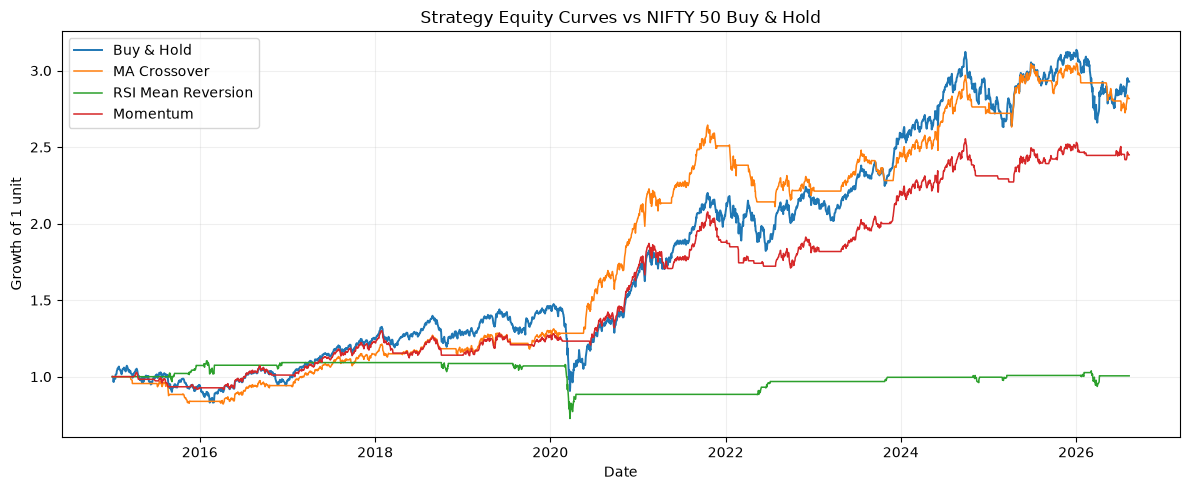

In [22]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(benchmark.index, benchmark["equity_curve"], label="Buy & Hold", linewidth=1.4)

for name, result in backtests.items():
    ax.plot(result.index, result["equity_curve"], label=name, linewidth=1.1)

ax.set_title("Strategy Equity Curves vs NIFTY 50 Buy & Hold")
ax.set_xlabel("Date")
ax.set_ylabel("Growth of 1 unit")
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()


## Cost check

This confirms that transaction costs are only charged when the executed position changes.


In [23]:
cost_check = []

for name, result in backtests.items():
    cost_check.append({
        "Strategy": name,
        "Turnover": result["turnover"].sum(),
        "Total Cost": result["cost"].sum(),
        "Days With Cost": int((result["cost"] > 0).sum()),
    })

cost_check = pd.DataFrame(cost_check).set_index("Strategy")
display(cost_check.round(6))


,Turnover,Total Cost,Days With Cost
Strategy,,,
MA Crossover,51.0,0.0255,51
RSI Mean Reversion,30.0,0.0150,30
Momentum,117.0,0.0585,117


## Save the Phase 2 result


In [24]:
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

comparison_path = RESULTS_DIR / "strategy_comparison.csv"
strategy_comparison.to_csv(comparison_path)

print("Saved:", comparison_path)
print("\nPhase 2 complete.")


Saved: c:\quantitative-trading-backtesting\results\strategy_comparison.csv

Phase 2 complete.


# Phase 3 — Regimes and Robustness

This part checks whether the strategy behaviour changes across different market conditions and whether the moving-average result is sensitive to the chosen parameters.

I also test higher and lower transaction-cost assumptions instead of relying on one cost value.


## Market regimes

I use a simple 200-day moving average rule:

- Bull: close is more than 2% above SMA 200
- Bear: close is more than 2% below SMA 200
- Sideways: everything in between

The regime label is shifted by one day for the performance comparison, so the label is based only on information already known before that day's return.


In [25]:
market["SMA_200"] = market["Close"].rolling(200).mean()

distance_from_sma200 = market["Close"] / market["SMA_200"] - 1

raw_regime = pd.Series("Sideways", index=market.index, dtype="object")
raw_regime[distance_from_sma200 > 0.02] = "Bull"
raw_regime[distance_from_sma200 < -0.02] = "Bear"
raw_regime[market["SMA_200"].isna()] = np.nan

# Use yesterday's regime for today's return analysis.
market["Regime"] = raw_regime.shift(1)

print(market["Regime"].value_counts(dropna=False))


Regime
Bull        1769
Bear         474
Sideways     413
NaN          199
None           1
Name: count, dtype: int64


## Strategy performance by regime


In [26]:
def regime_metrics(returns):
    returns = returns.dropna()

    if len(returns) == 0:
        return {
            "Days": 0,
            "Total Return": np.nan,
            "Annualized Return": np.nan,
            "Annualized Volatility": np.nan,
            "Sharpe Ratio": np.nan,
            "Positive Day Rate": np.nan,
        }

    total_return = (1 + returns).prod() - 1
    annual_return = returns.mean() * TRADING_DAYS
    annual_vol = returns.std(ddof=1) * np.sqrt(TRADING_DAYS)
    sharpe = annual_return / annual_vol if annual_vol > 0 else np.nan

    return {
        "Days": len(returns),
        "Total Return": total_return,
        "Annualized Return": annual_return,
        "Annualized Volatility": annual_vol,
        "Sharpe Ratio": sharpe,
        "Positive Day Rate": (returns > 0).mean(),
    }


regime_rows = []

all_returns = {
    "Buy & Hold": benchmark["net_return"],
    **{name: result["net_return"] for name, result in backtests.items()},
}

for strategy_name, returns in all_returns.items():
    for regime_name in ["Bull", "Bear", "Sideways"]:
        mask = market["Regime"] == regime_name
        metrics = regime_metrics(returns[mask])

        regime_rows.append({
            "Strategy": strategy_name,
            "Regime": regime_name,
            **metrics,
        })

regime_performance = pd.DataFrame(regime_rows)

display(
    regime_performance[
        ["Strategy", "Regime", "Days", "Total Return", "Sharpe Ratio"]
    ].round(4)
)


,Strategy,Regime,Days,Total Return,Sharpe Ratio
0,Buy & Hold,Bull,1769,0.9447,0.8302
1,Buy & Hold,Bear,474,0.3915,0.8043
2,Buy & Hold,Sideways,413,0.0998,0.4493
3,MA Crossover,Bull,1769,1.0325,0.9567
4,MA Crossover,Bear,474,0.2627,1.4930
5,MA Crossover,Sideways,413,0.2431,1.2488
6,RSI Mean Reversion,Bull,1769,-0.0030,-0.0310
7,RSI Mean Reversion,Bear,474,0.0794,0.2976
8,RSI Mean Reversion,Sideways,413,-0.0850,-0.9035
9,Momentum,Bull,1769,0.9304,0.8898


In [27]:
regime_path = RESULTS_DIR / "regime_performance.csv"
regime_performance.to_csv(regime_path, index=False)

print("Saved:", regime_path)


Saved: c:\quantitative-trading-backtesting\results\regime_performance.csv


## Regime chart


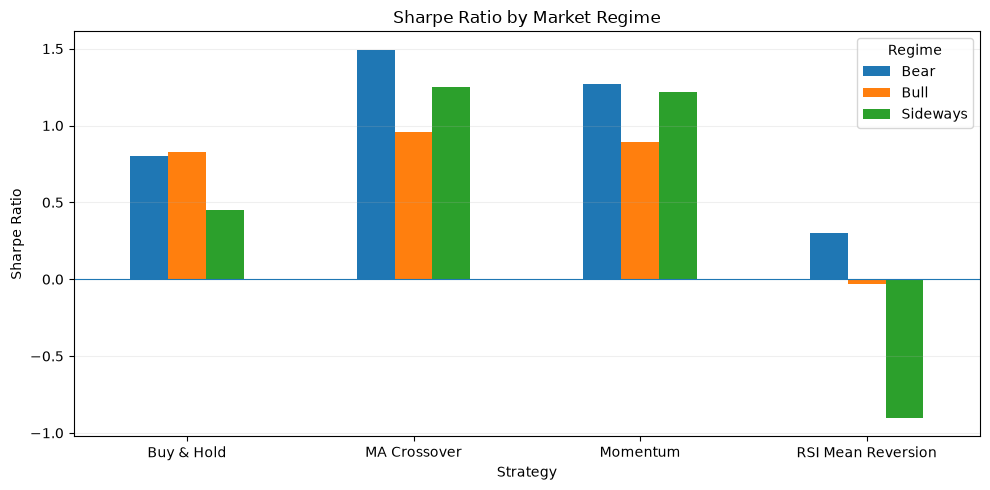

Saved: c:\quantitative-trading-backtesting\images\regime_performance.png


In [28]:
regime_plot = regime_performance.pivot(
    index="Strategy",
    columns="Regime",
    values="Sharpe Ratio",
)

ax = regime_plot.plot(kind="bar", figsize=(10, 5))
ax.set_title("Sharpe Ratio by Market Regime")
ax.set_xlabel("Strategy")
ax.set_ylabel("Sharpe Ratio")
ax.axhline(0, linewidth=0.8)
ax.grid(axis="y", alpha=0.2)

plt.xticks(rotation=0)
plt.tight_layout()

regime_image_path = IMAGE_DIR / "regime_performance.png"
plt.savefig(regime_image_path, dpi=160, bbox_inches="tight")
plt.show()

print("Saved:", regime_image_path)


## Moving-average parameter sensitivity

The goal here is not to pick the single highest historical return.  
I want to see whether the strategy behaves reasonably across several common short/long window combinations.


In [29]:
short_windows = [10, 20, 30]
long_windows = [50, 100, 200]

sensitivity_rows = []

for short_window in short_windows:
    for long_window in long_windows:
        if short_window >= long_window:
            continue

        test_position = ma_crossover_position(
            market,
            short_window=short_window,
            long_window=long_window,
        )

        test_result = run_backtest(
            market_returns=market["Daily_Return"],
            desired_position=test_position,
            transaction_cost=TRANSACTION_COST,
        )

        metrics = performance_metrics(
            test_result["net_return"],
            backtest_df=test_result,
        )

        sensitivity_rows.append({
            "Short Window": short_window,
            "Long Window": long_window,
            "Total Return": metrics["Total Return"],
            "CAGR": metrics["CAGR"],
            "Sharpe Ratio": metrics["Sharpe Ratio"],
            "Max Drawdown": metrics["Max Drawdown"],
            "Number of Trades": metrics["Number of Trades"],
        })

parameter_sensitivity = pd.DataFrame(sensitivity_rows)

display(parameter_sensitivity.round(4))


,Short Window,Long Window,Total Return,CAGR,Sharpe Ratio,Max Drawdown,Number of Trades
0,10,50,1.5783,0.0872,0.8641,-0.1448,33
1,10,100,1.6296,0.0891,0.8760,-0.1459,20
2,10,200,0.9687,0.0616,0.6051,-0.2613,15
3,20,50,1.8176,0.0957,0.9092,-0.2017,26
4,20,100,1.1461,0.0697,0.6946,-0.2110,15
5,20,200,0.7281,0.0495,0.4933,-0.2584,12
6,30,50,1.2731,0.0751,0.7285,-0.2353,24
7,30,100,1.0491,0.0653,0.6550,-0.1682,15
8,30,200,0.5889,0.0417,0.4200,-0.3441,9


In [30]:
sensitivity_path = RESULTS_DIR / "parameter_sensitivity.csv"
parameter_sensitivity.to_csv(sensitivity_path, index=False)

print("Saved:", sensitivity_path)


Saved: c:\quantitative-trading-backtesting\results\parameter_sensitivity.csv


## Sensitivity chart


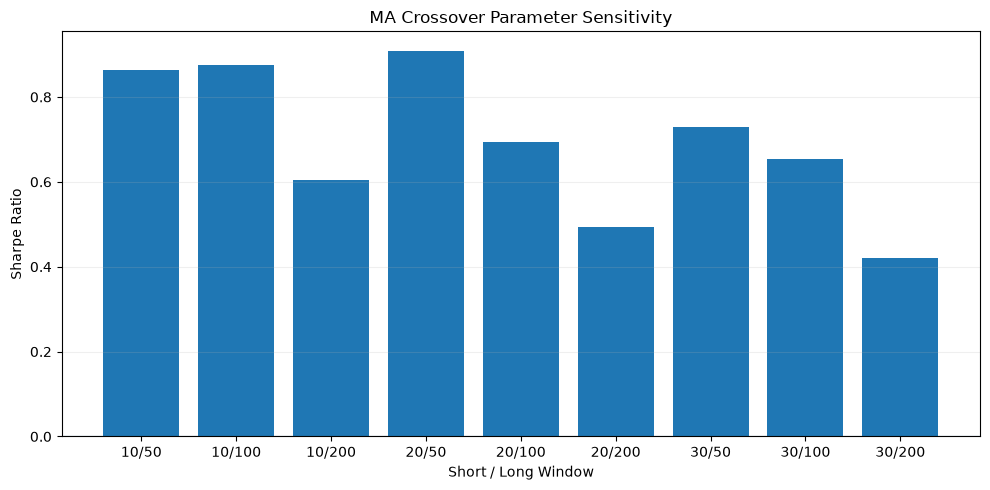

Saved: c:\quantitative-trading-backtesting\images\parameter_sensitivity.png


In [31]:
sensitivity_plot = parameter_sensitivity.copy()
sensitivity_plot["MA Pair"] = (
    sensitivity_plot["Short Window"].astype(str)
    + "/"
    + sensitivity_plot["Long Window"].astype(str)
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(sensitivity_plot["MA Pair"], sensitivity_plot["Sharpe Ratio"])
ax.set_title("MA Crossover Parameter Sensitivity")
ax.set_xlabel("Short / Long Window")
ax.set_ylabel("Sharpe Ratio")
ax.axhline(0, linewidth=0.8)
ax.grid(axis="y", alpha=0.2)

plt.tight_layout()

sensitivity_image_path = IMAGE_DIR / "parameter_sensitivity.png"
plt.savefig(sensitivity_image_path, dpi=160, bbox_inches="tight")
plt.show()

print("Saved:", sensitivity_image_path)


## Transaction-cost sensitivity

A strategy that only works under one very low cost assumption is not very convincing.  
This check reruns all three strategies at several cost levels.


In [32]:
cost_levels = [0.0, 0.00025, 0.0005, 0.001]
cost_rows = []

for cost_level in cost_levels:
    for strategy_name, position in positions.items():
        test_result = run_backtest(
            market_returns=market["Daily_Return"],
            desired_position=position,
            transaction_cost=cost_level,
        )

        metrics = performance_metrics(test_result["net_return"])

        cost_rows.append({
            "Strategy": strategy_name,
            "Transaction Cost": cost_level,
            "Total Return": metrics["Total Return"],
            "CAGR": metrics["CAGR"],
            "Sharpe Ratio": metrics["Sharpe Ratio"],
            "Max Drawdown": metrics["Max Drawdown"],
        })

transaction_cost_sensitivity = pd.DataFrame(cost_rows)

display(transaction_cost_sensitivity.round(4))


,Strategy,Transaction Cost,Total Return,CAGR,Sharpe Ratio,Max Drawdown
0,MA Crossover,0.0000,1.8905,0.0982,0.9307,-0.1993
1,RSI Mean Reversion,0.0000,0.0207,0.0018,0.0668,-0.3389
2,Momentum,0.0000,1.5975,0.0879,0.8968,-0.1677
3,MA Crossover,0.0002,1.8538,0.0969,0.9200,-0.2005
4,RSI Mean Reversion,0.0002,0.0131,0.0011,0.0597,-0.3403
5,Momentum,0.0002,1.5226,0.0851,0.8707,-0.1722
6,MA Crossover,0.0005,1.8176,0.0957,0.9092,-0.2017
7,RSI Mean Reversion,0.0005,0.0055,0.0005,0.0525,-0.3416
8,Momentum,0.0005,1.4499,0.0823,0.8446,-0.1768
9,MA Crossover,0.0010,1.7465,0.0932,0.8877,-0.2041


In [33]:
cost_sensitivity_path = RESULTS_DIR / "transaction_cost_sensitivity.csv"
transaction_cost_sensitivity.to_csv(cost_sensitivity_path, index=False)

print("Saved:", cost_sensitivity_path)


Saved: c:\quantitative-trading-backtesting\results\transaction_cost_sensitivity.csv


## Phase 3 check


In [34]:
print("Files created:")
print("-", regime_path.name)
print("-", sensitivity_path.name)
print("-", cost_sensitivity_path.name)
print("-", regime_image_path.name)
print("-", sensitivity_image_path.name)

print("\nPhase 3 complete.")


Files created:
- regime_performance.csv
- parameter_sensitivity.csv
- transaction_cost_sensitivity.csv
- regime_performance.png
- parameter_sensitivity.png

Phase 3 complete.
